<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/hr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR & compensation (104 employees)

**Applied AI Academy — problem set with worked answers**

**Rows:** 104  ·  **Source file:** `latvia_hr_employees.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/latvia_hr_employees.csv"
LOCAL = "latvia_hr_employees.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (104, 7)


,first_name,last_name,department,position,years_experience,salary_eur,satisfaction
0,Jānis,Bērziņš,IT,Sistēmu administrators,8,2200,Apmierināts
1,Anna,Kalniņa,Mārketings,Mārketinga speciāliste,3,1500,Ļoti apmierināts
2,Pēteris,Ozoliņš,Pārdošana,Pārdošanas menedžeris,12,2800,Neitrāls
3,Līga,Jansone,Personāla daļa,Personāla speciāliste,5,1700,Apmierināts
4,Mārtiņš,Vītols,Finanses,Finanšu analītiķis,7,2500,Apmierināts


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
first_name            str
last_name             str
department            str
position              str
years_experience    int64
salary_eur          int64
satisfaction          str

No missing values.


---
## Problem 1 · Easy — describe

Describe the workforce.

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Employees: {len(df)}")
print("\nBy department:\n", df["department"].value_counts())
print("\nSalary (EUR):\n", df["salary_eur"].describe().round(0))
print("\nSatisfaction:\n", df["satisfaction"].value_counts())

Employees: 104

By department:
 department
IT                21
Ražošana          20
Pārdošana         18
Mārketings        17
Finanses          17
Personāla daļa    11
Name: count, dtype: int64

Salary (EUR):
 count     104.0
mean     2246.0
std       898.0
min       600.0
25%      1600.0
50%      1975.0
75%      2825.0
max      5500.0
Name: salary_eur, dtype: float64

Satisfaction:
 satisfaction
Apmierināts           42
Ļoti apmierināts      26
Neitrāls              22
Neapmierināts         12
Ļoti neapmierināts     2
Name: count, dtype: int64


---
## Problem 2 · Intermediate — build

Where does pay actually differ?

*Try it yourself first. The worked solution is below.*

In [4]:
d = (df.groupby("department")
       .agg(n=("salary_eur","size"), median_salary=("salary_eur","median"),
            median_exp=("years_experience","median"))
       .sort_values("median_salary", ascending=False))
print(d.round(1))
print(f"\nCorrelation experience vs salary: {df['years_experience'].corr(df['salary_eur']):.2f}")

                 n  median_salary  median_exp
department                                   
IT              21         2900.0         8.0
Finanses        17         2800.0         8.0
Pārdošana       18         2100.0         6.5
Mārketings      17         1900.0         4.0
Ražošana        20         1750.0         8.0
Personāla daļa  11         1700.0         5.0

Correlation experience vs salary: 0.79


---
## Problem 3 · Advanced — judge

Is experience or department the better explanation? Say which, with numbers.

*Try it yourself first. The worked solution is below.*

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
X1 = df[["years_experience"]]
X2 = pd.get_dummies(df[["years_experience","department"]], drop_first=True)
y = df["salary_eur"]
r1 = LinearRegression().fit(X1, y).score(X1, y)
r2 = LinearRegression().fit(X2, y).score(X2, y)
print(f"R2 using experience only:            {r1:.3f}")
print(f"R2 using experience + department:    {r2:.3f}")
print(f"Explanatory power added by department: {r2-r1:+.3f}")
print("\nWith n=%d this is descriptive, not causal — and far too small a sample" % len(df))
print("to justify any individual pay decision. Say that out loud in the room.")

R2 using experience only:            0.630
R2 using experience + department:    0.812
Explanatory power added by department: +0.181

With n=104 this is descriptive, not causal — and far too small a sample
to justify any individual pay decision. Say that out loud in the room.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


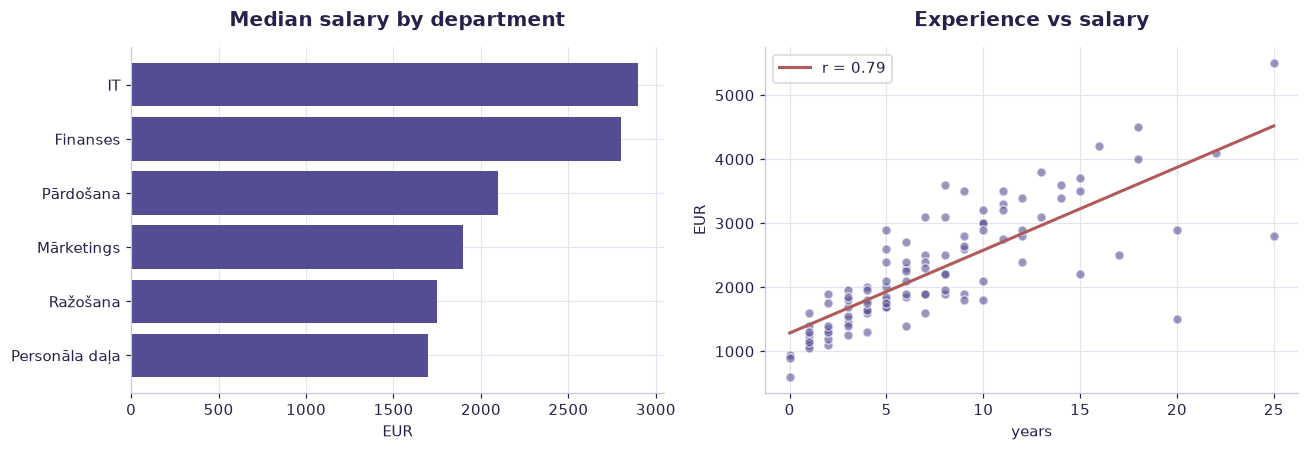

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
d = df.groupby("department")["salary_eur"].median().sort_values()
ax[0].barh(d.index, d.values, color=ACCENT)
ax[0].set_title("Median salary by department"); ax[0].set_xlabel("EUR")

ax[1].scatter(df["years_experience"], df["salary_eur"], alpha=.6, color=ACCENT, edgecolor="white")
z = np.polyfit(df["years_experience"], df["salary_eur"], 1)
xs = np.linspace(df["years_experience"].min(), df["years_experience"].max(), 50)
ax[1].plot(xs, np.polyval(z, xs), color=DANGER, lw=2,
           label=f"r = {df['years_experience'].corr(df['salary_eur']):.2f}")
ax[1].set_title("Experience vs salary"); ax[1].set_xlabel("years"); ax[1].set_ylabel("EUR"); ax[1].legend()
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Avg salary €2,246 (range €600–€5,500). By department: IT €2,869 > Finance €2,626 > Sales €2,214 > Marketing €1,985 > Production €1,845 > HR €1,655
2. Experience↔salary correlation = 0.79 — strong, but not causal (seniority, role, department confound it)
3. satisfaction is ORDINAL: the order matters but gaps aren't equal — don't average it into a "3.4"
4. Teaching point: this one table contains nominal, ordinal, and ratio variables — the data-types lesson made concrete


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.


---
*Applied AI Academy · appliedai.center*
